# 1数据加载和分析

In [ ]:
from sklearn.datasets import fetch_20newsgroups
import os

os.environ['http_proxy'] = ''
os.environ['https_proxy'] = ''
# os.environ['SCIKIT_LEARN_DATA'] = '~/scikit_learn_data/'

# 加载数据集
categories = ['alt.atheism', 'soc.religion.christian', 'comp.graphics', 'sci.med']
newsgroups_train = fetch_20newsgroups(subset='train', categories=categories)
newsgroups_test = fetch_20newsgroups(subset='test', categories=categories)

sample = {
    "text_preview": newsgroups_train.data[0],
    "category": newsgroups_train.target[0]
}

print(sample)


{'text_preview': 'From: sd345@city.ac.uk (Michael Collier)\nSubject: Converting images to HP LaserJet III?\nNntp-Posting-Host: hampton\nOrganization: The City University\nLines: 14\n\nDoes anyone know of a good way (standard PC application/PD utility) to\nconvert tif/img/tga files into LaserJet III format.  We would also like to\ndo the same, converting to HPGL (HP plotter) files.\n\nPlease email any response.\n\nIs this the correct group?\n\nThanks in advance.  Michael.\n-- \nMichael Collier (Programmer)                 The Computer Unit,\nEmail: M.P.Collier@uk.ac.city                The City University,\nTel: 071 477-8000 x3769                      London,\nFax: 071 477-8565                            EC1V 0HB.\n', 'category': 1}


['hello', ',', 'world', '!']


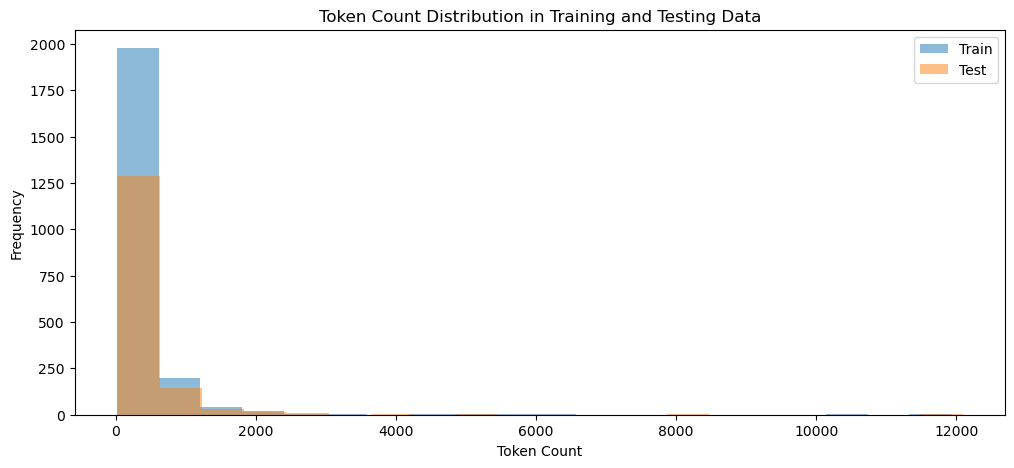

In [24]:
import re
import matplotlib.pyplot as plt

# 训练集和测试集数据长度分布

def basic_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9(),.!?\'`]", " ", text) # 将非字母、数字、标点符号、引号等字符替换为空格
    text = re.sub(r"([,.!?\'`])", r" \1 ", text) # 将标点符号前后添加空格
    return text.strip().split() # 返回一个列表，列表中的每个元素是一个单词

print(basic_tokenize("Hello,  world!"))

train_lengths = [len(basic_tokenize(text)) for text in newsgroups_train.data]
test_lengths = [len(basic_tokenize(text)) for text in newsgroups_test.data]

# 绘制训练集和测试集数据长度分布
plt.figure(figsize=(12, 5))
plt.hist(train_lengths, bins=20, alpha=0.5, label='Train')
plt.hist(test_lengths, bins=20, alpha=0.5, label='Test')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.title('Token Count Distribution in Training and Testing Data')
plt.legend()
plt.show()

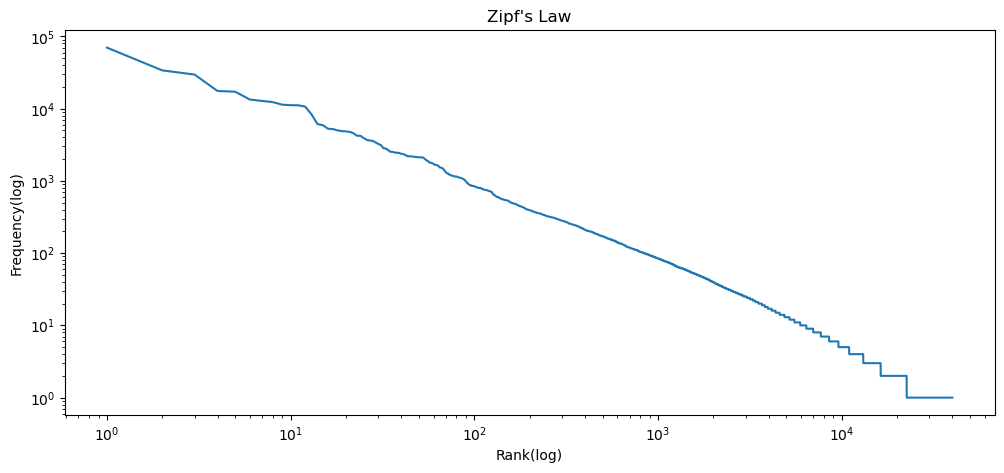

In [25]:
from collections import Counter

word_counts = Counter()

for text in newsgroups_train.data:
    words = basic_tokenize(text)
    word_counts.update(words)

frequencies = sorted(word_counts.values(), reverse=True)

ranks = range(1, len(frequencies) + 1)

plt.figure(figsize=(12, 5))
plt.loglog(ranks, frequencies) # 对数坐标轴
plt.xlabel('Rank(log)')
plt.ylabel('Frequency(log)')
plt.title('Zipf\'s Law')
plt.show()


# 2定义所需组件

In [26]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# 查看一下特殊token和词汇表大小
print(f"UNK token: '{tokenizer.unk_token}', ID: {tokenizer.unk_token_id}")
print(f"PAD token: '{tokenizer.pad_token}', ID: {tokenizer.pad_token_id}")
print(f"CLS token: '{tokenizer.cls_token}', ID: {tokenizer.cls_token_id}")
print(f"SEP token: '{tokenizer.sep_token}', ID: {tokenizer.sep_token_id}")
print(f"Vocab size: {tokenizer.vocab_size}")

print(tokenizer.encode("hello, world!"))
print(tokenizer.decode([101, 7592, 1010, 2088, 999, 102]))

UNK token: '[UNK]', ID: 100
PAD token: '[PAD]', ID: 0
CLS token: '[CLS]', ID: 101
SEP token: '[SEP]', ID: 102
Vocab size: 30522
[101, 7592, 1010, 2088, 999, 102]
[CLS] hello, world! [SEP]


In [27]:
from torch.utils.data import Dataset
from tqdm import tqdm

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.processed_data = []
        for text, label in tqdm(zip(texts, labels), total=len(texts)):
            tokens = tokenizer.encode(text)
            if len(tokens) <= max_length:
                self.processed_data.append((tokens, label))
            else:
                stride = max(1, int(max_length * 0.8))
                for i in range(0, len(tokens)-max_length+1, stride):
                    chunk = tokens[i:i+max_length]
                    self.processed_data.append((chunk, label))

    def __len__(self):
        return len(self.processed_data)
    
    def __getitem__(self, index):
        return self.processed_data[index]

In [28]:
import torch


def bert_collate_fn(batch):
    max_batch_len = max(len(item[0]) for item in batch)

    batch_input_ids, batch_attention_masks, batch_labels = [], [], []

    for item in batch:
        input_ids = item[0]
        padding_len = max_batch_len - len(input_ids)

        padded_ids = input_ids + [tokenizer.pad_token_id] * padding_len
        # 新增：生成 attention_mask
        attention_mask = [1] * len(input_ids) + [0] * padding_len

        batch_input_ids.append(padded_ids)
        batch_attention_masks.append(attention_mask)
        batch_labels.append(item[1])

    return {
        "input_ids": torch.tensor(batch_input_ids, dtype=torch.long),
        # 新增：返回 attention_mask
        "attention_mask": torch.tensor(batch_attention_masks, dtype=torch.long),
        "labels": torch.tensor(batch_labels, dtype=torch.long),
    }


In [29]:
from torch.utils.data import DataLoader

train_dataset = TextDataset(newsgroups_train.data, newsgroups_train.target, tokenizer)
test_dataset = TextDataset(newsgroups_test.data, newsgroups_test.target, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=bert_collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=bert_collate_fn)

batch1 = next(iter(train_loader))
print(len(train_dataset))
print(len(test_dataset))
print(batch1)

100%|██████████| 1502/1502 [00:09<00:00, 154.23it/s]

9992
7457
{'input_ids': tensor([[ 2420,  1000,  1010,  ...,  4873,  1012,  1045],
        [ 1008,  1008,  1008,  ...,  1008,  1008,  1008],
        [ 2683,  2549,  1030,  ...,  1012,  1012,  1012],
        ...,
        [ 3686,  1007,  7009,  ...,  4427,  2011,  2643],
        [  101,  2013,  1024,  ...,  2108, 27792,  1997],
        [  101,  2013,  1024,  ...,  5254,  2852,  1012]]), 'attention_mask': tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]]), 'labels': tensor([3, 1, 0, 3, 0, 1, 1, 3, 2, 2, 0, 3, 3, 2, 1, 3, 1, 0, 2, 3, 0, 0, 2, 3,
        0, 0, 3, 0, 0, 0, 0, 2])}


# 3模型构建

In [30]:
import torch.nn as nn
import torch.optim as optim
from transformers import BertModel, BertTokenizer

class TextClassificationBert(nn.Module):
    def __init__(self, model_name, num_classes, freeze_bert=False):
        super(TextClassificationBert, self).__init__()

        self.bert = BertModel.from_pretrained(model_name)

        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)
        
        if freeze_bert:
            self.freeze_bert_parameters()
    
    def freeze_bert_parameters(self):
        for param in self.bert.parameters():
            param.requires_grad = False
            
    def forward(self, input_ids, attention_mask):
        # input_ids: [batch_size, seq_length]
        outputs = self.bert(input_ids, attention_mask)
        cls_output = outputs.pooler_output
        return self.fc(cls_output)

In [35]:
import os
import json

class Trainer:
    def __init__(self, model, optimizer, lr_scheduler,criterion, train_loader, valid_loader, device, output_dir="."):
        self.model = model
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.criterion = criterion
        self.train_loader = train_loader
        self.valid_loader = valid_loader
        self.device = device
        self.best_accuracy = 0.0
        self.output_dir = output_dir
        os.makedirs(self.output_dir, exist_ok=True)
        self.train_losses = []
        self.val_accuracies = []
        

    def _run_epoch(self, epoch):
        self.model.train()
        total_loss = 0
        for batch in tqdm(self.train_loader, desc=f"Epoch {epoch+1} [训练中]"):
            self.optimizer.zero_grad()
            
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            labels = batch["labels"].to(self.device)
            
            outputs = self.model(input_ids, attention_mask)
            loss = self.criterion(outputs, labels)
            total_loss += loss.item()
            
            loss.backward()
            self.optimizer.step()
        
        return total_loss / len(self.train_loader)

    def _evaluate(self, epoch):
        self.model.eval()
        correct_preds = 0
        total_samples = 0
        with torch.no_grad():
            for batch in tqdm(self.valid_loader, desc=f"Epoch {epoch+1} [评估中]"):
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                labels = batch["labels"].to(self.device)
                
                outputs = self.model(input_ids, attention_mask)
                _, predicted = torch.max(outputs, 1)
                
                total_samples += labels.size(0)
                correct_preds += (predicted == labels).sum().item()
        
        return correct_preds / total_samples

    def _save_checkpoint(self, epoch, val_accuracy):
        if val_accuracy > self.best_accuracy:
            self.best_accuracy = val_accuracy
            self.model.bert.save_pretrained(self.output_dir)
            # 单独保存fc层
            save_path = os.path.join(self.output_dir, "classifier.pth")
            torch.save(self.model.fc.state_dict(), save_path)
            print(f"新最佳模型已保存! Epoch: {epoch+1}, 验证集准确率: {val_accuracy:.4f}")

    def train(self, epochs, tokenizer, label_map):
        self.train_losses = []
        self.val_accuracies = []
        for epoch in range(epochs):
            avg_loss = self._run_epoch(epoch)
            val_accuracy = self._evaluate(epoch)
            
            self.train_losses.append(avg_loss)
            self.val_accuracies.append(val_accuracy)

            print(f"Epoch {epoch+1}/{epochs} | 训练损失: {avg_loss:.4f} | 验证集准确率: {val_accuracy:.4f}")
            
            self._save_checkpoint(epoch, val_accuracy)
            # self.lr_scheduler.step()  # 每 epoch 一次，StepLR.step_size 才表示「每 N 个 epoch」
        
        print("训练完成！")
        # 保存tokenizer
        tokenizer.save_pretrained(self.output_dir)
        labels_path = os.path.join(self.output_dir, 'label_map.json')
        with open(labels_path, 'w', encoding='utf-8') as f:
           json.dump(label_map, f, ensure_ascii=False, indent=4)
        print(f"tokenizer 和标签映射 ({labels_path}) 已保存。")
        return self.train_losses, self.val_accuracies

In [32]:
class Predictor:
    def __init__(self, model, tokenizer, label_map, device, max_len=128):
        self.model = model.to(device)
        self.model.eval()
        self.tokenizer = tokenizer
        self.label_map = label_map
        self.id_to_label = {int(idx): label for label, idx in self.label_map.items()}
        self.device = device
        self.max_len = max_len

    def predict(self, text):
        # 使用bert tokenizer进行分词，但不截断
        encoding = self.tokenizer(text, add_special_tokens=True, truncation=False)
        token_ids = encoding['input_ids']

        # 同样的分块逻辑
        chunks, chunk_masks = [], []
        if len(token_ids) <= self.max_len:
            chunks.append(token_ids)
        else:
            stride = max(1, int(self.max_len * 0.8))
            for i in range(0, len(token_ids) - self.max_len + 1, stride):
                chunks.append(token_ids[i:i + self.max_len])
        
        if not chunks:
            return "无法预测（文本过短或分词后为空）"

        # 对分块进行padding
        max_chunk_len = max(len(c) for c in chunks)
        
        padded_chunks, attention_masks = [], []
        for chunk in chunks:
            padding_len = max_chunk_len - len(chunk)
            padded_chunks.append(chunk + [self.tokenizer.pad_token_id] * padding_len)
            attention_masks.append([1] * len(chunk) + [0] * padding_len)
            
        # 转换为tensor
        input_ids_tensor = torch.tensor(padded_chunks, dtype=torch.long).to(self.device)
        attention_mask_tensor = torch.tensor(attention_masks, dtype=torch.long).to(self.device)
        
        # 批量推理所有分块
        with torch.no_grad():
            outputs = self.model(input_ids=input_ids_tensor, attention_mask=attention_mask_tensor)
            preds = torch.argmax(outputs, dim=1)

        # 投票得出最终结果
        final_pred_id = torch.bincount(preds).argmax().item()
        
        final_pred_label = self.id_to_label[final_pred_id]
        return final_pred_label

# 4模型训练

In [36]:
hparams = {
    "model_name": "bert-base-uncased",
    "num_classes": len(categories),
    "freeze_bert": False,
    "learning_rate": 2e-5,
    "epoch": 10,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "output_dir": "output_03"
}

label_map = {name: i for i, name in enumerate(newsgroups_train.target_names)}

model = TextClassificationBert(
    model_name=hparams["model_name"],
    num_classes=hparams["num_classes"],
    freeze_bert=hparams["freeze_bert"]
).to(hparams["device"])

optimizer = optim.Adam(model.parameters(), lr=hparams["learning_rate"])
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
criterion = nn.CrossEntropyLoss()

trainer = Trainer(model, optimizer, lr_scheduler, criterion, train_loader, test_loader, hparams["device"], hparams["output_dir"])
train_losses, val_accuracies = trainer.train(epochs=hparams["epoch"], tokenizer=tokenizer, label_map=label_map)


Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Epoch 1 [评估中]: 100%|██████████| 234/234 [00:49<00:00,  4.69it/s]


Epoch 1/10 | 训练损失: 0.5091 | 验证集准确率: 0.8784
新最佳模型已保存! Epoch: 1, 验证集准确率: 0.8784


Epoch 2 [评估中]: 100%|██████████| 234/234 [00:51<00:00,  4.57it/s]


Epoch 2/10 | 训练损失: 0.1668 | 验证集准确率: 0.8874
新最佳模型已保存! Epoch: 2, 验证集准确率: 0.8874


Epoch 3 [评估中]: 100%|██████████| 234/234 [00:51<00:00,  4.59it/s]


...

Epoch 8/10 | 训练损失: 0.0140 | 验证集准确率: 0.9008


Epoch 9 [评估中]: 100%|██████████| 234/234 [00:51<00:00,  4.58it/s]


Epoch 9/10 | 训练损失: 0.0137 | 验证集准确率: 0.8865


Epoch 10 [评估中]: 100%|██████████| 234/234 [00:51<00:00,  4.57it/s]

Epoch 10/10 | 训练损失: 0.0177 | 验证集准确率: 0.8896
训练完成！
tokenizer 和标签映射 (output_03/label_map.json) 已保存。


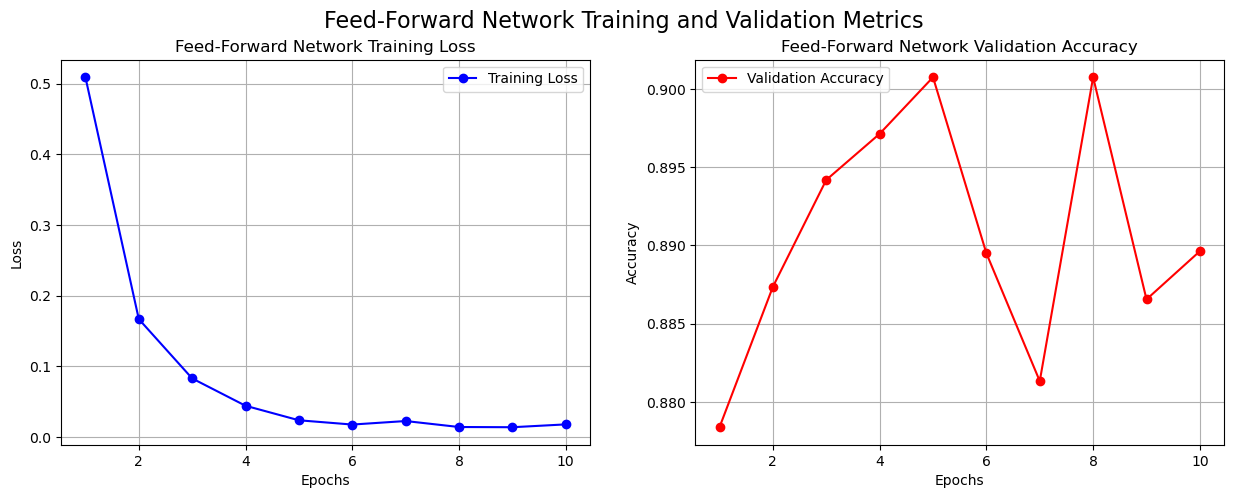

In [37]:
def plot_history(train_losses, val_accuracies, title_prefix=""):
    epochs = range(1, len(train_losses) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot Training Loss
    ax1.plot(epochs, train_losses, 'bo-', label='Training Loss')
    ax1.set_title(f'{title_prefix} Training Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    ax1.legend()
    
    # Plot Validation Accuracy
    ax2.plot(epochs, val_accuracies, 'ro-', label='Validation Accuracy')
    ax2.set_title(f'{title_prefix} Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)
    ax2.legend()
    
    plt.suptitle(f'{title_prefix} Training and Validation Metrics', fontsize=16)
    plt.show()

plot_history(train_losses, val_accuracies, title_prefix="Feed-Forward Network")

# 5 模型预测

In [39]:
# 加载资源
labels_path = os.path.join(hparams["output_dir"], 'label_map.json')
with open(labels_path, 'r', encoding='utf-8') as f:
    label_map_loaded = json.load(f)

# 实例化推理组件
inference_tokenizer = BertTokenizer.from_pretrained(hparams["output_dir"])

inference_model = TextClassificationBert(
    model_name=hparams["output_dir"],  # 从保存的目录加载bert
    num_classes=len(label_map_loaded)
).to(hparams["device"])

# 加载分类头的权重
classifier_path = os.path.join(hparams["output_dir"], "classifier.pth")
inference_model.fc.load_state_dict(
    torch.load(classifier_path, map_location=hparams["device"]))


<All keys matched successfully>

In [41]:
predictor = Predictor(
    inference_model, 
    inference_tokenizer, 
    label_map_loaded, 
    hparams["device"]
)

# 预测
new_text = "The doctor prescribed a new medicine for the patient's illness, focusing on its gpu accelerated healing properties."
predicted_class = predictor.predict(new_text)

{"text": new_text, "pred": predicted_class}

{'text': "The doctor prescribed a new medicine for the patient's illness, focusing on its gpu accelerated healing properties.",
 'pred': 'sci.med'}